# Video: additional encoder experiments (frozen)

Run this notebook twice by switching `FACE_ENCODER`/`RUN_DIR` to test the two additional video encoders.


In [13]:
from pathlib import Path

# ===== Paths =====
DATA_DIR   = Path("/home/danila/networks/data")
TRAIN_CSV  = DATA_DIR / "train_split.csv"
VALID_CSV  = DATA_DIR / "valid_split.csv"

# Face emb dir
FACE_ENCODER_OPTIONS = {
    "emotieff_enet_b0_8": "faces_emotiefflib_enet_b0_8_fps5_v1",
    "emotieff_enet_b3_8": "faces_emotiefflib_enet_b3_8_fps5_v1",
}
FACE_ENCODER = "emotieff_enet_b0_8"  # change to the second option for another run

FACE_DIR   = Path('/home/danila/networks/data/embeddings/faces_emotiefflib_enet_b0_8_best_vgaf_fps5_v1') #DATA_DIR / "embeddings" / FACE_ENCODER_OPTIONS[FACE_ENCODER]

RUN_TAG = "video_faces_emotieff_enet_b0_8_v1"  # change per encoder
RUN_DIR    = DATA_DIR / "runs" / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH  = RUN_DIR / "best_by_corr.pt"
HIST_PATH  = RUN_DIR / "history.json"

# For statistics
STATS_PATH = RUN_DIR / "emb_stats.npz"
PCA_PATH   = RUN_DIR / "pca_ipca.npz"

# ===== Task =====
EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
NUM_TARGETS = 6
ID_WIDTH = 5

# ===== Frame geometry (for area ratio) =====
FRAME_W = 1280
FRAME_H = 720

# ===== Data filtering =====
MIN_VALID_FRAMES = 5   # minimum of valid frames per video

# ===== Embedding preprocessing =====
USE_ZSCORE = True
CLIP_K = 6.0           # clip после z-score: [-k, k]

USE_PCA = False
PCA_DIM = 256
PCA_BATCH_FRAMES = 4096  # how many frames per iteration for IPCA

# ===== Temporal feature engineering =====
USE_EMA_SMOOTH = False
EMA_BETA = 0.5         # 0.3..0.6 is usually ok

USE_DELTAS = False      # add Δ and Δ2
# final input dim = D' or 3*D'

# ===== Training =====
DEVICE = "cuda"
SEED = 42

BATCH_SIZE = 10
NUM_WORKERS = 0
PIN_MEMORY = False

D_MODEL = 128
TCN_LAYERS = 4
TCN_KERNEL = 3
DROPOUT = 0.4
ATTN_HIDDEN = 128
ATTN_TEMP = 1.5

LR = 3e-5
WEIGHT_DECAY = 3e-2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA = 1e-4

USE_AMP = True
GRAD_CLIP_NORM = 1.0

# ===== Loss: Pearson accumulated + small SmoothL1 =====
ACCUM_STEPS = 4
LAMBDA_SMOOTH = 0.02  # 0.05

# ===== Augmentations on embeddings =====
USE_TIME_MASK = False
TIME_MASK_PROB = 0.3
TIME_MASK_NUM = 1
TIME_MASK_MAX_RATIO = 0.08


In [14]:
import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("CUDA:", torch.cuda.is_available(), "| DEVICE:", DEVICE)

CUDA: True | DEVICE: cuda


In [15]:
def load_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)     # (T,D)
    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), dtype=bool)

    face_prob = d["face_prob"].astype(np.float32) if "face_prob" in d.files else np.ones((emb.shape[0],), np.float32)

    bbox = d["bbox_xyxy"].astype(np.float32) if "bbox_xyxy" in d.files else np.full((emb.shape[0],4), -1, np.float32)

    ts = d["timestamps_sec"].astype(np.float32) if "timestamps_sec" in d.files else None
    return emb, valid, face_prob, bbox, ts

def filter_existing_face(df: pd.DataFrame, face_dir: Path, id_width=5, min_valid=5):
    keep = []
    miss = []
    columns = list(df.columns)
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Filter face npz"):
        vid = str(row["Filename"]).zfill(id_width)
        p = face_dir / f"{vid}.npz"
        if not p.exists():
            miss.append({"video_id": vid, "reason": "face_npz_missing"})
            continue
        try:
            emb, valid, *_ = load_face_npz(p)
            if valid.sum() < min_valid:
                miss.append({"video_id": vid, "reason": f"too_few_valid<{min_valid}"})
                continue
        except Exception as e:
            miss.append({"video_id": vid, "reason": f"npz_read_error:{repr(e)}"})
            continue
        keep.append(row.to_dict())
    return pd.DataFrame(keep, columns=columns).reset_index(drop=True), pd.DataFrame(miss)

In [16]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})
train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

assert FACE_DIR.exists(), f"FACE_DIR not found: {FACE_DIR}. Generate embeddings first or change FACE_ENCODER/FACE_DIR."
assert all(c in train_df.columns for c in ["Filename", *EMOTIONS]), f"Missing train columns: {[c for c in ['Filename', *EMOTIONS] if c not in train_df.columns]}"
assert all(c in valid_df.columns for c in ["Filename", *EMOTIONS]), f"Missing valid columns: {[c for c in ['Filename', *EMOTIONS] if c not in valid_df.columns]}"

train_df, train_miss = filter_existing_face(train_df, FACE_DIR, ID_WIDTH, MIN_VALID_FRAMES)
valid_df, valid_miss = filter_existing_face(valid_df, FACE_DIR, ID_WIDTH, MIN_VALID_FRAMES)

print("Train ok:", len(train_df), "missing:", len(train_miss))
print("Val   ok:", len(valid_df), "missing:", len(valid_miss))

if len(train_df) == 0:
    raise RuntimeError(
        f"No usable training samples were found in {FACE_DIR}. "
        "This usually means the selected FACE_ENCODER points to a missing or wrong embeddings folder, "
        "or the embeddings were not generated yet."
    )
if len(valid_df) == 0:
    raise RuntimeError(
        f"No usable validation samples were found in {FACE_DIR}. "
        "Check FACE_ENCODER/FACE_DIR and available .npz embeddings."
    )

pd.concat([train_miss.assign(split="train"), valid_miss.assign(split="val")]) \
  .to_csv(RUN_DIR / "missing_faces.csv", index=False)

# target norm stats
y_train = train_df[EMOTIONS].values.astype(np.float32)
y_mean = y_train.mean(axis=0)
y_std  = np.clip(y_train.std(axis=0), 1e-3, None)
np.savez(RUN_DIR / "target_norm.npz", y_mean=y_mean, y_std=y_std, emotions=np.array(EMOTIONS))

print("y_mean:", y_mean)
print("y_std :", y_std)

Filter face npz: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [00:04<00:00, 1067.15it/s]

Train ok: 7813 missing: 259
Val   ok: 236 missing: 4352
y_mean: [0.17835365 0.12548369 0.09744883 0.02115019 0.14249489 0.1152411 ]
y_std : [0.25001416 0.21870056 0.18827994 0.09510664 0.22851111 0.21242902]


In [17]:
from sklearn.decomposition import IncrementalPCA

def compute_emb_stats_and_pca(train_df: pd.DataFrame):
    # Welford mean/var
    n = 0
    mean = None
    M2 = None

    # IPCA
    ipca = IncrementalPCA(n_components=PCA_DIM) if USE_PCA else None
    buf = []

    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Compute emb stats/PCA"):
        vid = row["Filename"]
        p = FACE_DIR / f"{vid}.npz"
        emb, valid, *_ = load_face_npz(p)
        emb = emb[valid]
        if emb.shape[0] == 0:
            continue

        # Welford update batch-wise
        if mean is None:
            D = emb.shape[1]
            mean = np.zeros((D,), dtype=np.float64)
            M2 = np.zeros((D,), dtype=np.float64)

        for x in emb:
            n += 1
            delta = x - mean
            mean += delta / n
            delta2 = x - mean
            M2 += delta * delta2

        # buffer for IPCA
        if USE_PCA:
            buf.append(emb.astype(np.float32))
            if sum(b.shape[0] for b in buf) >= PCA_BATCH_FRAMES:
                X = np.concatenate(buf, axis=0)
                # z-score before PCA
                ipca.partial_fit(X)
                buf = []

    var = (M2 / max(1, n-1)).astype(np.float64)
    std = np.sqrt(np.maximum(var, 1e-12)).astype(np.float64)

    if USE_PCA and buf:
        X = np.concatenate(buf, axis=0).astype(np.float32)
        ipca.partial_fit(X)

    # save
    np.savez(STATS_PATH, emb_mean=mean.astype(np.float32), emb_std=std.astype(np.float32), n=n)
    print("Saved stats:", STATS_PATH, "| frames used:", n)

    if USE_PCA:
        # saving the components/mean ipca
        np.savez(PCA_PATH,
                 components=ipca.components_.astype(np.float32),
                 pca_mean=ipca.mean_.astype(np.float32),
                 explained_variance=ipca.explained_variance_.astype(np.float32))
        print("Saved PCA:", PCA_PATH, "| dim:", PCA_DIM)

compute_emb_stats_and_pca(train_df)

Compute emb stats/PCA: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7813/7813 [02:01<00:00, 64.46it/s]

Saved stats: /home/danila/networks/data/runs/video_faces_emotieff_enet_b0_8_v1/emb_stats.npz | frames used: 1744896


In [18]:
stats = np.load(STATS_PATH, allow_pickle=False)
emb_mean = stats["emb_mean"].astype(np.float32)
emb_std  = stats["emb_std"].astype(np.float32)

if USE_PCA:
    pca = np.load(PCA_PATH, allow_pickle=False)
    W = pca["components"].astype(np.float32)      # [PCA_DIM, D]
    pca_mean = pca["pca_mean"].astype(np.float32) # [D]
else:
    W = None
    pca_mean = None

def apply_transform(emb: np.ndarray) -> np.ndarray:
    x = emb
    if USE_ZSCORE:
        x = (x - emb_mean[None, :]) / emb_std[None, :]
        if CLIP_K is not None:
            x = np.clip(x, -CLIP_K, CLIP_K)
    if USE_PCA:
        # sklearn PCA transform: (x - pca_mean) @ components.T
        x = (x - pca_mean[None, :]) @ W.T
    return x.astype(np.float32)

def ema_smooth(x: np.ndarray, valid: np.ndarray, beta: float) -> np.ndarray:
    # x: [T,D]
    if not USE_EMA_SMOOTH:
        return x
    out = x.copy()
    prev = None
    for t in range(x.shape[0]):
        if not valid[t]:
            # we don't update it, but we leave it as it is
            continue
        if prev is None:
            out[t] = x[t]
            prev = out[t].copy()
        else:
            prev = beta * x[t] + (1.0 - beta) * prev
            out[t] = prev
    return out

def compute_deltas(x: np.ndarray, valid: np.ndarray):
    # x: [T,D]
    if not USE_DELTAS:
        return x
    dx = np.zeros_like(x)
    d2 = np.zeros_like(x)
    for t in range(1, x.shape[0]):
        if valid[t] and valid[t-1]:
            dx[t] = x[t] - x[t-1]
        else:
            dx[t] = 0.0
    for t in range(2, x.shape[0]):
        if valid[t] and valid[t-1] and valid[t-2]:
            d2[t] = dx[t] - dx[t-1]
        else:
            d2[t] = 0.0
    return np.concatenate([x, dx, d2], axis=1)  # [T, 3D]

def quality_from_prob_area(face_prob: np.ndarray, bbox: np.ndarray, valid: np.ndarray):
    # bbox: [T,4] xyxy
    x1, y1, x2, y2 = bbox[:,0], bbox[:,1], bbox[:,2], bbox[:,3]
    w = np.clip(x2 - x1, 0, None)
    h = np.clip(y2 - y1, 0, None)
    area = w * h
    area_ratio = area / float(FRAME_W * FRAME_H + 1e-6)
    q = face_prob * np.sqrt(np.clip(area_ratio, 0, 1))
    q = np.clip(q, 0.0, 1.0)
    q = q.astype(np.float32)
    q[~valid] = 0.0
    return q

In [19]:
class FaceEmbDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        vid = str(row["Filename"]).zfill(ID_WIDTH)
        p = FACE_DIR / f"{vid}.npz"

        emb, valid, face_prob, bbox, ts = load_face_npz(p)

        # transform embeddings
        x = apply_transform(emb)
        x = ema_smooth(x, valid, EMA_BETA)
        x = compute_deltas(x, valid)

        # quality
        q = quality_from_prob_area(face_prob, bbox, valid)

        # target normalized
        y = np.array([row[e] for e in EMOTIONS], dtype=np.float32)
        y = (y - y_mean) / y_std

        return {"video_id": vid, "x": x, "mask": valid.astype(bool), "q": q, "y": y}


MAX_T_CAP = 1000  # 20 сек * 5 fps = 100 (или сделайте параметром)

def collate_pad(batch):
    lengths = [min(b["x"].shape[0], MAX_T_CAP) for b in batch]
    maxT = max(lengths)
    Din = batch[0]["x"].shape[1]

    x = torch.zeros((len(batch), maxT, Din), dtype=torch.float32)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    q = torch.zeros((len(batch), maxT), dtype=torch.float32)
    y = torch.zeros((len(batch), NUM_TARGETS), dtype=torch.float32)
    vids = []

    for i, b in enumerate(batch):
        T = min(b["x"].shape[0], MAX_T_CAP)
        x[i, :T] = torch.from_numpy(b["x"][:T])
        mask[i, :T] = torch.from_numpy(b["mask"][:T])
        q[i, :T] = torch.from_numpy(b["q"][:T])
        y[i] = torch.from_numpy(b["y"])
        vids.append(b["video_id"])

    return {"video_id": vids, "x": x, "mask": mask, "q": q, "y": y}

train_ds = FaceEmbDataset(train_df)
valid_ds = FaceEmbDataset(valid_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          collate_fn=collate_pad, drop_last=False, persistent_workers=(NUM_WORKERS>0))
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          collate_fn=collate_pad, drop_last=False, persistent_workers=(NUM_WORKERS>0))

b = next(iter(train_loader))
print(b["x"].shape, b["mask"].shape, b["q"].shape, b["y"].shape)

torch.Size([10, 622, 1280]) torch.Size([10, 622]) torch.Size([10, 622]) torch.Size([10, 6])


In [20]:
def apply_time_mask(x: torch.Tensor, mask: torch.Tensor):
    if not USE_TIME_MASK:
        return x
    B, T, _ = x.shape
    for b in range(B):
        if random.random() > TIME_MASK_PROB:
            continue
        valid_idx = mask[b].nonzero(as_tuple=False).squeeze(1)
        if valid_idx.numel() < 10:
            continue
        valid_T = int(valid_idx.numel())
        max_len = max(1, int(valid_T * TIME_MASK_MAX_RATIO))
        for _ in range(TIME_MASK_NUM):
            span = random.randint(1, max_len)
            start = random.randint(0, max(0, valid_T - span))
            t0 = int(valid_idx[start].item())
            t1 = int(valid_idx[start + span - 1].item()) + 1
            x[b, t0:t1] = 0.0
    return x

In [21]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1,2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1,2)  # [B,T,d]

class QualityAttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )
        # learnable weight for quality bias
        self.q_alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x, mask, q):
        # x: [B,T,d], mask: [B,T], q: [B,T] in [0,1]
        logits = self.attn(x).squeeze(-1) / self.temp  # [B,T]

        # quality bias: log(q+eps)
        qb = torch.log(q.clamp_min(1e-4))
        logits = logits + self.q_alpha * qb

        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class VideoFaceModel(nn.Module):
    def __init__(self, din: int, d_model: int, tcn_layers: int, tcn_kernel: int, dropout: float, attn_hidden: int, temp: float):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(din, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = QualityAttentiveStatsPooling(d_model, attn_hidden, dropout, temp=temp)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, NUM_TARGETS),
        )

    def forward(self, x, mask, q):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask, q)
        return self.head(z)

In [22]:
def pearson_corr_torch(preds, targets, eps=1e-8):
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + eps)
    return corr.mean()

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def train_epoch_pearson_accum(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    group_losses = []
    all_pred, all_y = [], []

    buf_p, buf_y = [], []
    buf_count = 0

    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        q = batch["q"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)

        # aug
        x = apply_time_mask(x, m)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            p = model(x, m, q)

        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

        buf_p.append(p)
        buf_y.append(y)
        buf_count += 1

        flush = (buf_count >= ACCUM_STEPS) or (step == len(loader))
        if not flush:
            continue

        optimizer.zero_grad(set_to_none=True)
        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            loss_main = 1.0 - pearson_corr_torch(P, Y)
            loss = loss_main + (LAMBDA_SMOOTH * smooth_loss_fn(P, Y) if LAMBDA_SMOOTH > 0 else 0.0)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_pred, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    return {"loss": train_loss, "corr": train_corr}

@torch.inference_mode()
def eval_epoch(model, loader):
    model.eval()
    all_pred, all_y = [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        q = batch["q"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        p = model(x, m, q)
        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())
    P = torch.cat(all_pred, dim=0)
    Y = torch.cat(all_y, dim=0)
    corr = float(pearson_corr_torch(P, Y).item())
    loss = float((1.0 - corr) + (LAMBDA_SMOOTH * smooth_loss_fn(P, Y).item() if LAMBDA_SMOOTH > 0 else 0.0))
    return {"loss": loss, "corr": corr}

In [23]:
b = next(iter(train_loader))
DIN = b["x"].shape[-1]
print("Input dim:", DIN)

model = VideoFaceModel(DIN, D_MODEL, TCN_LAYERS, TCN_KERNEL, DROPOUT, ATTN_HIDDEN, temp=ATTN_TEMP).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

# steps per epoch in "groups"
steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
total_steps = MAX_EPOCHS * steps_per_epoch
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print(model)

Input dim: 1280
VideoFaceModel(
  (proj): Sequential(
    (0): Linear(in_features=1280, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.4, inplace=False)
  )
  (enc): TCNEncoder(
    (blocks): ModuleList(
      (0): TCNBlock(
        (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (norm1): GroupNorm(1, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(1, 128, eps=1e-05, affine=True)
        (drop): Dropout(p=0.4, inplace=False)
      )
      (1): TCNBlock(
        (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (norm1): GroupNorm(1, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(1, 128, eps=1e-05, affine=True)
        (drop): Dropout(p=0.4, inplace=False)
      

/tmp/ipykernel_88708/864348461.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))


In [24]:
history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}

best_corr = -1e9
best_epoch = -1
bad = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr = train_epoch_pearson_accum(model, train_loader, optimizer, scaler, scheduler=scheduler)
    va = eval_epoch(model, valid_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr["loss"])
    history["train_corr"].append(tr["corr"])
    history["val_loss"].append(va["loss"])
    history["val_corr"].append(va["corr"])
    history["lr"].append(lr_now)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {tr['loss']:.4f} corr {tr['corr']:.4f} | "
        f"val loss {va['loss']:.4f} corr {va['corr']:.4f} | "
        f"lr {lr_now:.2e}"
    )

    if (va["corr"] - best_corr) > MIN_DELTA:
        best_corr = va["corr"]
        best_epoch = epoch
        bad = 0
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "best_corr": best_corr}, CKPT_PATH)
        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        print(f"  ✅ Saved best-by-corr: epoch={epoch}, val_corr={best_corr:.4f}")
    else:
        bad += 1
        print(f"  ⏳ no corr improve: {bad}/{PATIENCE}")

    if bad >= PATIENCE:
        print(f"@ Early stopping. Best epoch={best_epoch}, best val corr={best_corr:.4f}")
        break

train:   0%|                                                                                                                                                                      | 0/782 [00:00<?, ?it/s]/tmp/ipykernel_88708/3401377223.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
train:   0%|▌                                                                                                                                                             | 3/782 [00:01<04:34,  2.84it/s]/tmp/ipykernel_88708/3401377223.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
                                                                                                                                    

Epoch 001 | train loss 0.9931 corr 0.0195 | val loss 0.9094 corr 0.1028 | lr 1.20e-05
  ✅ Saved best-by-corr: epoch=1, val_corr=0.1028


Epoch 002 | train loss 0.9129 corr 0.1003 | val loss 0.8320 corr 0.1798 | lr 2.40e-05
  ✅ Saved best-by-corr: epoch=2, val_corr=0.1798


Epoch 003 | train loss 0.8609 corr 0.1528 | val loss 0.8281 corr 0.1843 | lr 3.00e-05
  ✅ Saved best-by-corr: epoch=3, val_corr=0.1843


Epoch 004 | train loss 0.8298 corr 0.1817 | val loss 0.8186 corr 0.1936 | lr 2.99e-05
  ✅ Saved best-by-corr: epoch=4, val_corr=0.1936


...

Epoch 013 | train loss 0.7151 corr 0.2981 | val loss 0.8056 corr 0.2047 | lr 2.65e-05
  ⏳ no corr improve: 4/8


Epoch 014 | train loss 0.7041 corr 0.3075 | val loss 0.8103 corr 0.2002 | lr 2.59e-05
  ⏳ no corr improve: 5/8


Epoch 015 | train loss 0.6997 corr 0.3139 | val loss 0.8078 corr 0.2025 | lr 2.52e-05
  ⏳ no corr improve: 6/8


Epoch 016 | train loss 0.6862 corr 0.3272 | val loss 0.8065 corr 0.2038 | lr 2.44e-05
  ⏳ no corr improve: 7/8


Epoch 017 | train loss 0.6818 corr 0.3334 | val loss 0.8114 corr 0.1990 | lr 2.36e-05
  ⏳ no corr improve: 8/8
@ Early stopping. Best epoch=9, best val corr=0.2102


Loaded best epoch: 9 best_corr: 0.2101747989654541


Final Train: {'loss': 0.7136636388301849, 'corr': 0.2975340187549591}
Final Val  : {'loss': 0.8005039668083191, 'corr': 0.2101747989654541}


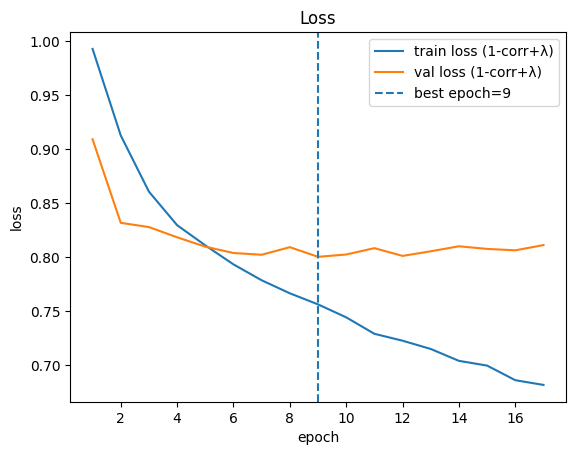

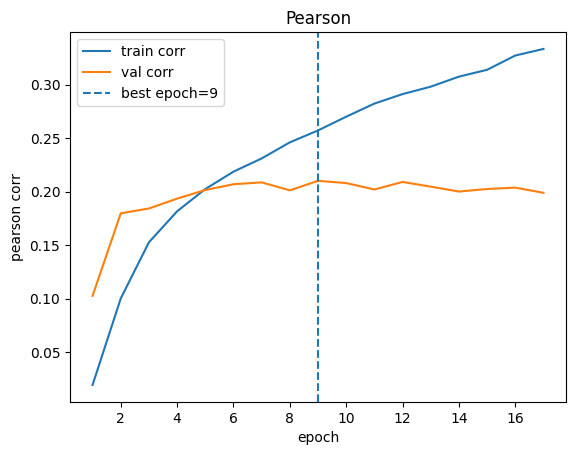

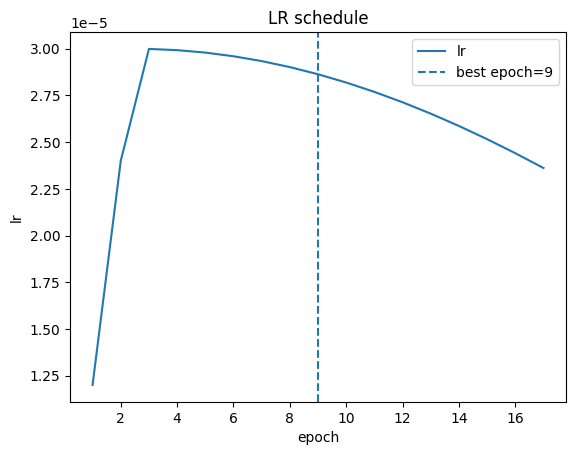

In [25]:
import matplotlib.pyplot as plt

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded best epoch:", ckpt["epoch"], "best_corr:", ckpt["best_corr"])

# final metrics
train_metrics = eval_epoch(model, train_loader)
val_metrics = eval_epoch(model, valid_loader)
print("Final Train:", train_metrics)
print("Final Val  :", val_metrics)

# graphs
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train loss (1-corr+λ)")
plt.plot(epochs, history["val_loss"], label="val loss (1-corr+λ)")
plt.axvline(ckpt["epoch"], linestyle="--", label=f"best epoch={ckpt['epoch']}")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["train_corr"], label="train corr")
plt.plot(epochs, history["val_corr"], label="val corr")
plt.axvline(ckpt["epoch"], linestyle="--", label=f"best epoch={ckpt['epoch']}")
plt.xlabel("epoch"); plt.ylabel("pearson corr"); plt.title("Pearson"); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["lr"], label="lr")
plt.axvline(ckpt["epoch"], linestyle="--", label=f"best epoch={ckpt['epoch']}")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.title("LR schedule"); plt.legend(); plt.show()

In [32]:
@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    Ps, Ys = [], []
    for batch in tqdm(loader, desc="collect", leave=False):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        q = batch["q"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        pred = model(x, m, q)
        Ps.append(pred.detach().float().cpu())
        Ys.append(y.detach().float().cpu())
    return torch.cat(Ps, dim=0), torch.cat(Ys, dim=0)

def f1_macro_from_regression(P, Y, thr=0.7, eps=1e-8):
    pb = (P >= thr).int()
    yb = (Y >= thr).int()
    tp = (pb & yb).sum(dim=0).float()
    fp = (pb & (1 - yb)).sum(dim=0).float()
    fn = ((1 - pb) & yb).sum(dim=0).float()
    f1 = (2 * tp) / (2 * tp + fp + fn + eps)
    return float(f1.mean().item()), [float(x) for x in f1]

P, Y = collect_preds(model, valid_loader)
P = P * torch.from_numpy(y_std).float() + torch.from_numpy(y_mean).float()
Y = Y * torch.from_numpy(y_std).float() + torch.from_numpy(y_mean).float()
f1_mean, f1_per = f1_macro_from_regression(P, Y, thr=0.5)
print("Val F1 (macro, thr=0.5):", f1_mean)
for e, v in zip(EMOTIONS, f1_per):
    print(f"{e:14s}: {v:.4f}")


Val F1 (macro, thr=0.5): 0.0
Admiration    : 0.0000
Amusement     : 0.0000
Determination : 0.0000
Empathic Pain : 0.0000
Excitement    : 0.0000
Joy           : 0.0000


In [30]:
# --- Per-emotion Pearson on validation set ---
@torch.no_grad()
def collect_preds_video(model, loader):
    model.eval()
    Ps, Ys = [], []
    for batch in tqdm(loader, desc="collect", leave=False):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        q = batch["q"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        pred = model(x, m, q)
        Ps.append(pred.detach().float().cpu())
        Ys.append(y.detach().float().cpu())
    return torch.cat(Ps, dim=0), torch.cat(Ys, dim=0)

def pearson_per_emotion(P: torch.Tensor, Y: torch.Tensor, eps: float = 1e-8):
    P = P.float()
    Y = Y.float()
    vx = P - P.mean(dim=0, keepdim=True)
    vy = Y - Y.mean(dim=0, keepdim=True)
    num = (vx * vy).sum(dim=0)
    den = torch.sqrt((vx * vx).sum(dim=0) * (vy * vy).sum(dim=0)) + eps
    corr = num / den
    return float(corr.mean().item()), [float(c.item()) for c in corr]

P, Y = collect_preds_video(model, valid_loader)
P = P * torch.from_numpy(y_std).float() + torch.from_numpy(y_mean).float()
Y = Y * torch.from_numpy(y_std).float() + torch.from_numpy(y_mean).float()
mean_corr, per_corr = pearson_per_emotion(P, Y)
print("Val mean Pearson:", mean_corr)
for e, c in zip(EMOTIONS, per_corr):
    print(f"{e:14s}: {c:.4f}")


Val mean Pearson: 0.21017484366893768
Admiration    : 0.0205
Amusement     : 0.2875
Determination : 0.2552
Empathic Pain : 0.1395
Excitement    : 0.1912
Joy           : 0.3672


In [33]:
# --- Save best finetuned video encoder/head ---
import shutil

ckpt = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.to(DEVICE).eval()

EXPORT_DIR = RUN_DIR / "finetuned_encoder"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_MODEL_PATH = EXPORT_DIR / "video_model.pt"
EXPORT_META_PATH = EXPORT_DIR / "meta.json"

torch.save(
    {
        "model_state": model.state_dict(),
        "epoch": int(ckpt.get("epoch", -1)),
        "best_corr": float(ckpt.get("best_corr", float("nan"))),
        "config": {
            "face_encoder": FACE_ENCODER,
            "face_dir": str(FACE_DIR),
            "d_model": int(D_MODEL),
            "tcn_layers": int(TCN_LAYERS),
            "tcn_kernel": int(TCN_KERNEL),
            "dropout": float(DROPOUT),
            "attn_hidden": int(ATTN_HIDDEN),
            "attn_temp": float(ATTN_TEMP),
            "num_targets": int(NUM_TARGETS),
            "max_t_cap": int(MAX_T_CAP),
            "use_zscore": bool(USE_ZSCORE),
            "clip_k": None if CLIP_K is None else float(CLIP_K),
            "use_pca": bool(USE_PCA),
            "pca_dim": int(PCA_DIM),
            "use_ema_smooth": bool(USE_EMA_SMOOTH),
            "ema_beta": float(EMA_BETA),
            "use_deltas": bool(USE_DELTAS),
            "frame_w": int(FRAME_W),
            "frame_h": int(FRAME_H),
            "emotions": EMOTIONS,
        },
    },
    EXPORT_MODEL_PATH,
)

meta = {
    "checkpoint_loaded": str(CKPT_PATH),
    "export_model_path": str(EXPORT_MODEL_PATH),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_corr": float(ckpt.get("best_corr", float("nan"))),
    "face_encoder": FACE_ENCODER,
    "face_dir": str(FACE_DIR),
    "stats_path": str(STATS_PATH),
    "pca_path": str(PCA_PATH) if USE_PCA else None,
    "target_norm_path": str(RUN_DIR / "target_norm.npz"),
}
with open(EXPORT_META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

if STATS_PATH.exists():
    shutil.copy2(STATS_PATH, EXPORT_DIR / STATS_PATH.name)
if USE_PCA and PCA_PATH.exists():
    shutil.copy2(PCA_PATH, EXPORT_DIR / PCA_PATH.name)
target_norm_path = RUN_DIR / "target_norm.npz"
if target_norm_path.exists():
    shutil.copy2(target_norm_path, EXPORT_DIR / target_norm_path.name)

print("Saved finetuned video encoder/head to:", EXPORT_DIR)
print("Model:", EXPORT_MODEL_PATH)
print("Meta :", EXPORT_META_PATH)


Saved finetuned video encoder/head to: /home/danila/networks/data/runs/video_faces_emotieff_enet_b0_8_v1/finetuned_encoder
Model: /home/danila/networks/data/runs/video_faces_emotieff_enet_b0_8_v1/finetuned_encoder/video_model.pt
Meta : /home/danila/networks/data/runs/video_faces_emotieff_enet_b0_8_v1/finetuned_encoder/meta.json
